In [25]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from wordcloud import WordCloud

# Descargamos los recursos de NLTK necesarios (solo la primera vez)
recursos = ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4', 'vader_lexicon']
for r in recursos:
    nltk.download(r, quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [26]:
url = "https://raw.githubusercontent.com/Noelia1986-A/data-c1/refs/heads/main/ag_news_train.csv"

df = pd.read_csv(url, index_col=0)

print(df.shape)
df.head()


(8000, 1)


,label
text,
"Red Hat Appoints New CFO. September 2, 2004 -- (WEB HOST INDUSTRY REVIEW) -- Linux distributor Red Hat (redhat.com) announced on Thursday that it has appointed Charles E. Peters, Jr.",Sci_Tech
"Sprint, SBC In Hotspot Roaming Deal. Sprint and SBC Communications Friday announced a two-way roaming deal that will enable the customers of each vendor to access the hotspots run by the other.",Sci_Tech
Radio Outage Grounds West Coast Flights. Airport operations were back to normal early Wednesday following a radio failure at a Federal Aviation Administration control facility that tied up travelers for hours.,Business
"Hollywood lawsuits to strike Net pirates. Hollywood studios are about to take the long-anticipated step of firing a barrage of lawsuits at some of the most prolific Internet pirates, echoing the legal strategy that the recording industry already has used with limited success.",Sci_Tech
Custis Takes Control. Family and Tony Robbins have matured and molded University of Maryland free safety Ray Custis into a trusted leader and anchor of the Terrapins' defense.,Sports


In [27]:
df.head(5)

,label
text,
"Red Hat Appoints New CFO. September 2, 2004 -- (WEB HOST INDUSTRY REVIEW) -- Linux distributor Red Hat (redhat.com) announced on Thursday that it has appointed Charles E. Peters, Jr.",Sci_Tech
"Sprint, SBC In Hotspot Roaming Deal. Sprint and SBC Communications Friday announced a two-way roaming deal that will enable the customers of each vendor to access the hotspots run by the other.",Sci_Tech
Radio Outage Grounds West Coast Flights. Airport operations were back to normal early Wednesday following a radio failure at a Federal Aviation Administration control facility that tied up travelers for hours.,Business
"Hollywood lawsuits to strike Net pirates. Hollywood studios are about to take the long-anticipated step of firing a barrage of lawsuits at some of the most prolific Internet pirates, echoing the legal strategy that the recording industry already has used with limited success.",Sci_Tech
Custis Takes Control. Family and Tony Robbins have matured and molded University of Maryland free safety Ray Custis into a trusted leader and anchor of the Terrapins' defense.,Sports


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, Red Hat Appoints New CFO. September 2, 2004 -- (WEB HOST INDUSTRY REVIEW) -- Linux distributor Red Hat (redhat.com) announced on Thursday that it has appointed Charles E. Peters, Jr. to Millions in Ethiopia Said to Need Food Aid (AP). AP - At least 4 million Ethiopians would die each year without food aid, a British aid group said Monday, marking 20 years since a devastating famine killed more than half a million people in the impoverished country.
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   8000 non-null   object
dtypes: object(1)
memory usage: 125.0+ KB


In [29]:
stop_words = set(stopwords.words('english'))
print(f"Cantidad de stopwords en inglés: {len(stop_words)}")
print(list(stop_words)[:15])


Cantidad de stopwords en inglés: 198
['didn', 'should', 'doesn', 'of', "wasn't", 'down', 'has', 'hasn', 'up', "wouldn't", 'the', "she'd", 'were', "hadn't", 'ours']


In [30]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', ' ', texto)   # solo letras
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def tokenizar_sin_stopwords(texto_limpio):
    tokens = word_tokenize(texto_limpio)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

# Reset the index to turn the 'text' index into a column
df_reset = df.reset_index()

df_reset['texto_limpio'] = df_reset['text'].apply(limpiar_texto)
df_reset['tokens'] = df_reset['texto_limpio'].apply(tokenizar_sin_stopwords)

df_reset[['text', 'texto_limpio', 'tokens']].head(5)

,text,texto_limpio,tokens
0,"Red Hat Appoints New CFO. September 2, 2004 --...",red hat appoints new cfo september web host in...,"[red, hat, appoints, new, cfo, september, web,..."
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",sprint sbc in hotspot roaming deal sprint and ...,"[sprint, sbc, hotspot, roaming, deal, sprint, ..."
2,Radio Outage Grounds West Coast Flights. Airpo...,radio outage grounds west coast flights airpor...,"[radio, outage, grounds, west, coast, flights,..."
3,Hollywood lawsuits to strike Net pirates. Holl...,hollywood lawsuits to strike net pirates holly...,"[hollywood, lawsuits, strike, net, pirates, ho..."
4,Custis Takes Control. Family and Tony Robbins ...,custis takes control family and tony robbins h...,"[custis, takes, control, family, tony, robbins..."


In [31]:
stemmer = PorterStemmer()

def aplicar_stemming(tokens):
    return [stemmer.stem(t) for t in tokens]

df_reset['tokens_stemming'] = df_reset['tokens'].apply(aplicar_stemming)

# Ejemplo comparativo
ejemplo = df_reset.loc[1, 'tokens']
print("Tokens originales:", ejemplo)
print("\nDespués de stemming:", [stemmer.stem(t) for t in ejemplo])

Tokens originales: ['sprint', 'sbc', 'hotspot', 'roaming', 'deal', 'sprint', 'sbc', 'communications', 'friday', 'announced', 'two', 'way', 'roaming', 'deal', 'enable', 'customers', 'vendor', 'access', 'hotspots', 'run']

Después de stemming: ['sprint', 'sbc', 'hotspot', 'roam', 'deal', 'sprint', 'sbc', 'commun', 'friday', 'announc', 'two', 'way', 'roam', 'deal', 'enabl', 'custom', 'vendor', 'access', 'hotspot', 'run']


In [32]:
lemmatizer = WordNetLemmatizer()

def aplicar_lematizacion(tokens):
    return [lemmatizer.lemmatize(t, pos='v') for t in tokens]  # pos='v' para tratar mejor los verbos

df_reset['tokens_lematizados'] = df_reset['tokens'].apply(aplicar_lematizacion)

ejemplo = df_reset.loc[1, 'tokens']
print("Tokens originales:   ", ejemplo)
print("\nDespués de lematizar:", [lemmatizer.lemmatize(t, pos='v') for t in ejemplo])

Tokens originales:    ['sprint', 'sbc', 'hotspot', 'roaming', 'deal', 'sprint', 'sbc', 'communications', 'friday', 'announced', 'two', 'way', 'roaming', 'deal', 'enable', 'customers', 'vendor', 'access', 'hotspots', 'run']

Después de lematizar: ['sprint', 'sbc', 'hotspot', 'roam', 'deal', 'sprint', 'sbc', 'communications', 'friday', 'announce', 'two', 'way', 'roam', 'deal', 'enable', 'customers', 'vendor', 'access', 'hotspots', 'run']


In [33]:
# Reconstruimos el texto lematizado como string para el vectorizador
df_reset['texto_lematizado'] = df_reset['tokens_lematizados'].apply(lambda tokens: ' '.join(tokens))

# Trabajamos con una muestra para que el vocabulario/matriz sea manejable de visualizar
muestra = df_reset.sample(2000, random_state=42).reset_index(drop=True)

bow_vectorizer = CountVectorizer(max_features=1000, min_df=5)
bow_matrix = bow_vectorizer.fit_transform(muestra['texto_lematizado'])

print("Forma de la matriz BoW (documentos x vocabulario):", bow_matrix.shape)
print("\nEjemplo de palabras del vocabulario:", bow_vectorizer.get_feature_names_out()[:20])

Forma de la matriz BoW (documentos x vocabulario): (2000, 1000)

Ejemplo de palabras del vocabulario: ['abuse' 'access' 'accord' 'account' 'accuse' 'acquire' 'acquisition'
 'across' 'action' 'add' 'administration' 'admit' 'advance' 'afghan'
 'afghanistan' 'afp' 'african' 'agency' 'ago' 'agree']


/tmp/ipykernel_7269/3677213901.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bow, x='frecuencia', y='palabra', palette='mako')


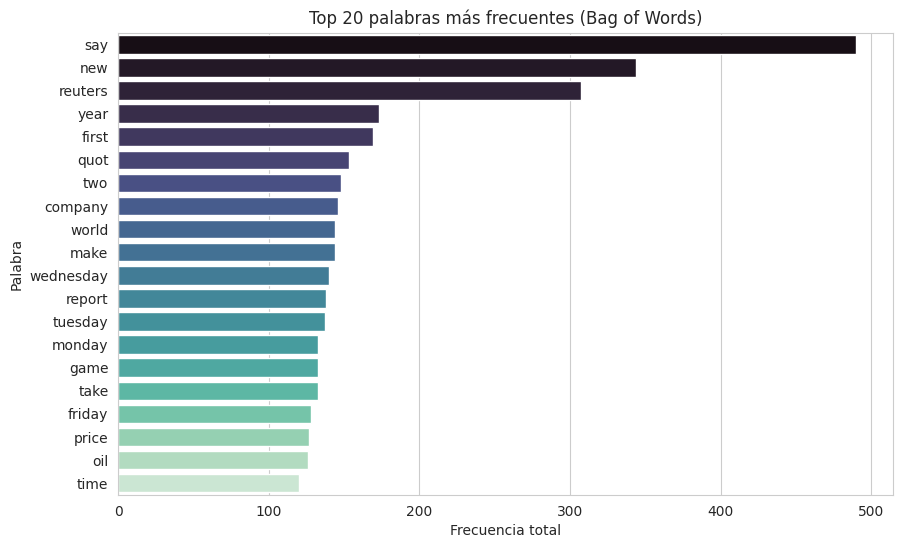

In [34]:
# Palabras más frecuentes según Bag of Words
frecuencias = np.asarray(bow_matrix.sum(axis=0)).flatten()
palabras = bow_vectorizer.get_feature_names_out()

top_bow = pd.DataFrame({'palabra': palabras, 'frecuencia': frecuencias}) \
            .sort_values('frecuencia', ascending=False) \
            .head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_bow, x='frecuencia', y='palabra', palette='mako')
plt.title('Top 20 palabras más frecuentes (Bag of Words)')
plt.xlabel('Frecuencia total')
plt.ylabel('Palabra')
plt.show()


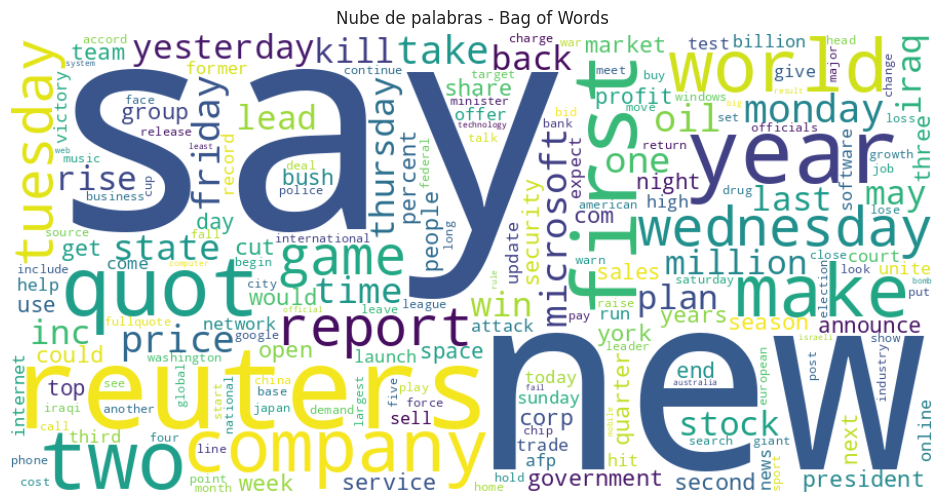

In [35]:
# Nube de palabras a partir de las frecuencias de BoW
frecuencias_dict = dict(zip(palabras, frecuencias))
wc = WordCloud(width=900, height=450, background_color='white', colormap='viridis')
wc.generate_from_frequencies(frecuencias_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Bag of Words')
plt.show()


In [36]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000, min_df=5)
tfidf_matrix = tfidf_vectorizer.fit_transform(muestra['texto_lematizado'])

print("Forma de la matriz TF-IDF:", tfidf_matrix.shape)


Forma de la matriz TF-IDF: (2000, 1000)


/tmp/ipykernel_7269/4192543196.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tfidf, x='peso_tfidf', y='palabra', palette='flare')


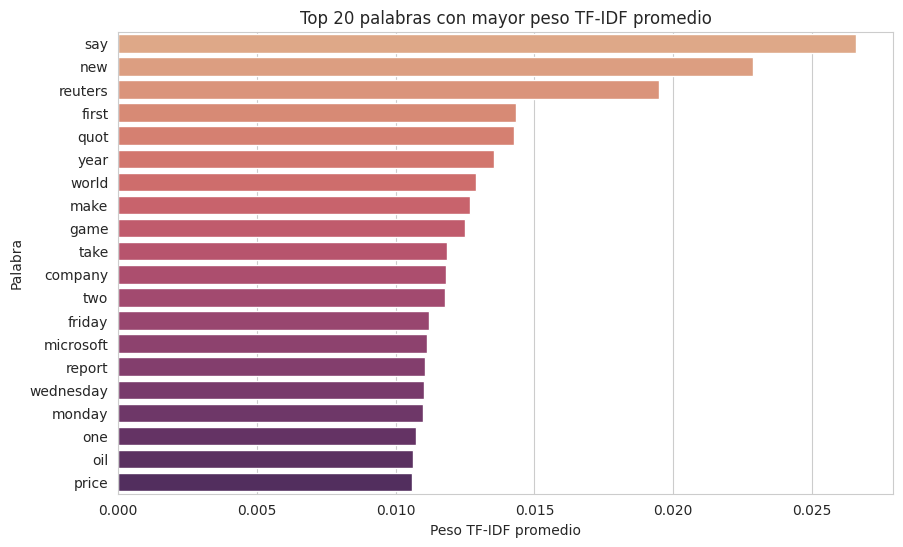

In [37]:
# Palabras con mayor peso TF-IDF promedio en todo el corpus muestreado
pesos_promedio = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
palabras_tfidf = tfidf_vectorizer.get_feature_names_out()

top_tfidf = pd.DataFrame({'palabra': palabras_tfidf, 'peso_tfidf': pesos_promedio}) \
              .sort_values('peso_tfidf', ascending=False) \
              .head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_tfidf, x='peso_tfidf', y='palabra', palette='flare')
plt.title('Top 20 palabras con mayor peso TF-IDF promedio')
plt.xlabel('Peso TF-IDF promedio')
plt.ylabel('Palabra')
plt.show()


In [38]:
# Ejemplo concreto: palabras más importantes (TF-IDF) de UNA reseña puntual
idx_ejemplo = 0
fila_tfidf = tfidf_matrix[idx_ejemplo].toarray().flatten()

top_palabras_reseña = pd.DataFrame({
    'palabra': palabras_tfidf,
    'tfidf': fila_tfidf
}).sort_values('tfidf', ascending=False).head(10)

print("Reseña analizada:")
print(muestra.loc[idx_ejemplo, 'text'])
print("\nPalabras más representativas según TF-IDF:")
top_palabras_reseña

Reseña analizada:
Earnings alert: Salesforce quarterly revenue rises. Plus: Write-downs widen DirecTV's loss...Time Warner net income slips...Cell phone unit shores up Verizon.

Palabras más representativas según TF-IDF:


,palabra,tfidf
153,cell,0.322855
952,warner,0.317969
444,income,0.309407
928,unit,0.295657
988,write,0.295657
755,revenue,0.287326
713,quarterly,0.282441
602,net,0.268281
281,earnings,0.264863
534,loss,0.257199


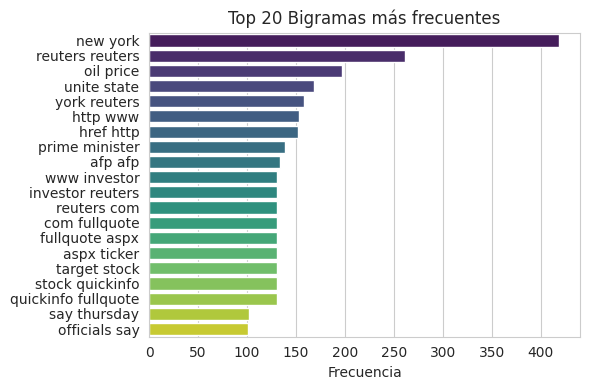

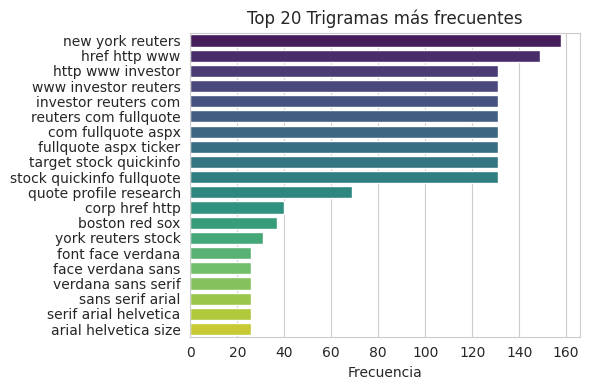

In [39]:
comentarios = df_reset['texto_lematizado'].astype(str)

def plot_top_ngrams(palabras, ngram_range=(2,2), top_n=10, title=''):
    # Crear un vectorizador para n-gramas (bigramas o trigramas)
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')  # podés cambiar stop_words a español si querés

    # Ajustar y transformar los comentarios
    X = vectorizer.fit_transform(palabras)

    # Sumar la frecuencia de cada n-grama
    suma_ngrams = X.sum(axis=0)

    # Mapear n-gramas con sus frecuencias
    ngrams_freq = [(ngram, suma_ngrams[0, idx]) for ngram, idx in vectorizer.vocabulary_.items()]

    # Ordenar por frecuencia descendente
    ngrams_freq = sorted(ngrams_freq, key=lambda x: x[1], reverse=True)[:top_n]

    # Convertir a DataFrame para graficar
    df_ngrams = pd.DataFrame(ngrams_freq, columns=['N-grama', 'Frecuencia'])

    # Graficar
    plt.figure(figsize=(6,4))
    sns.barplot(data=df_ngrams, y='N-grama', x='Frecuencia', palette='viridis', hue='N-grama', legend=False)
    plt.title(title)
    plt.xlabel('Frecuencia')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# Graficar los 20 bigramas más comunes
plot_top_ngrams(comentarios, ngram_range=(2,2), top_n=20, title='Top 20 Bigramas más frecuentes')

# Graficar los 20 trigramas más comunes
plot_top_ngrams(comentarios, ngram_range=(3,3), top_n=20, title='Top 20 Trigramas más frecuentes')

In [40]:
#Separo la data y labels
X = df_reset['texto_lematizado'].values
Y = df_reset['label'].values

In [41]:
# Convierto texto a numerico
vectorizer = TfidfVectorizer()
vectorizer.fit(X)

X = vectorizer.transform(X)

In [42]:
print(X.shape)
print(Y.shape)

(8000, 17112)
(8000,)


In [43]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 170183 stored elements and shape (8000, 17112)>
  Coords	Values
  (0, 635)	0.13058739260496066
  (0, 743)	0.4258542652770031
  (0, 2504)	0.24588838538738253
  (0, 2555)	0.22509215031312454
  (0, 2945)	0.13327599261645745
  (0, 4267)	0.24126346031453638
  (0, 6684)	0.40859183047773306
  (0, 7038)	0.1861102498975034
  (0, 7420)	0.1531489971486224
  (0, 8772)	0.18109818880542233
  (0, 10308)	0.08722649165086041
  (0, 11386)	0.27884963813626357
  (0, 12503)	0.30584512233311045
  (0, 12511)	0.27884963813626357
  (0, 12874)	0.19384580003232693
  (0, 13655)	0.1630176115757388
  (0, 15409)	0.11313137027654224
  (0, 16604)	0.15181532757625052
  (1, 75)	0.17255820332091204
  (1, 635)	0.12482323514572473
  (1, 2998)	0.1766204996918717
  (1, 3599)	0.16222135506843158
  (1, 3757)	0.25637650541887697
  (1, 4843)	0.20050691943528143
  (1, 5867)	0.10978703525637444
  :	:
  (7999, 1963)	0.13810672489737394
  (7999, 3388)	0.13154676179382735


In [44]:
from sklearn.model_selection import train_test_split

#Splitting the dataset to training & test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify=Y, random_state=2)

In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, Y_train)

LogisticRegression()

In [46]:
from sklearn.metrics import accuracy_score

# accuracy score on the training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('La acurassy de train es : ', training_data_accuracy)

La acurassy de train es :  0.9578125


In [47]:
# accuracy score on the test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('La accurasy de test es : ', test_data_accuracy)

La accurasy de test es :  0.87
